# BRICS scaffold

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from tqdm import tqdm
import seaborn as sns
import os
import sys
from collections import Counter
import numpy as np
current_dir = os.getcwd()
parent_parent_dir = os.path.dirname(os.path.dirname(current_dir))
src_dir = os.path.join(parent_parent_dir, 'src')
sys.path.append(src_dir)

from util import *

In [ ]:
df = pd.read_csv("../../data/processed/surechembl/molecular_descriptors_with_brics_fragments.csv")

In [4]:
df

,SMILES,BRICS_Fragments,BRICS_0,BRICS_1,BRICS_2,BRICS_3,BRICS_4,BRICS_5,BRICS_6,BRICS_7,BRICS_8,BRICS_9,BRICS_10,BRICS_11,BRICS_12,BRICS_13,BRICS_14,BRICS_15
0,CC(=O)Nc1ccccc1C(=O)c1ccccn1,[6*]C([6*])=O;[1*]C(C)=O;[14*]c1ccccn1;[16*]c1...,1,0,0,0,2,2,0,0,0,0,0,0,0,1,0,2
1,Nc1c(-c2ccccc2)ccnc1C(=O)c1nccc(-c2ccccc2)c1N,[14*]c1nccc([16*])c1N;[6*]C([6*])=O;[16*]c1ccccc1,0,0,0,0,0,2,0,0,0,0,0,0,0,1,0,2
2,Nc1ccccc1-c1cccnc1C=O,[16*]c1ccccc1N;[16*]c1cccnc1C=O,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
3,Nc1ccnc(C(=O)c2nccc(N)c2-c2ccccc2)c1-c1ccccc1,[14*]c1nccc(N)c1[16*];[16*]c1ccccc1;[6*]C([6*])=O,0,0,0,0,0,2,0,0,0,0,0,0,0,1,0,2
4,N#CCc1ccccc1,[8*]CC#N;[16*]c1ccccc1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22232539,COCCCOc1ccc(C(=O)Nc2cc(-c3nc4ccccc4[nH]3)[nH]n...,[5*]N[5*];[3*]O[3*];[3*]OC;[16*]c1ccc([16*])c(...,1,0,3,2,2,1,0,0,0,0,0,0,0,3,0,2
22232540,O=C(c1cccnc1-c1ccc(-c2n[nH]c3ncc(-c4ccc5c(c4)C...,[16*]c1ccc([16*])cc1;[14*]c1n[nH]c2ncc([16*])c...,1,0,0,0,2,1,0,0,0,0,0,0,0,2,1,5
22232541,O=C(NCCN1CCCCC1C(=O)O)OCC1c2ccccc2-c2ccccc21,[5*]N[5*];[3*]O[3*];[4*]CC1c2ccccc2-c2ccccc21;...,2,0,2,3,3,1,0,0,0,0,0,0,1,0,0,0
22232542,CCN(CC)C(=O)[C@@H]1C=C2c3cccc4[nH]cc(c34)C[C@H...,[5*]N1C[C@H]([15*])C=C2c3cccc4[nH]cc(c34)C[C@H...,1,0,0,2,4,1,0,1,0,0,0,0,0,0,1,1


In [ ]:
sc_smiles_date = pickle.load(open("../../data/processed/surechembl/250106_surechembl_smiles_date.pickle","rb"))

In [10]:
for i in tqdm(range(len(df))):
    smiles = df["SMILES"].iloc[i]
    if smiles in sc_smiles_date:
        df.at[i, "PATENT_DATE"] = sc_smiles_date[smiles]
    else:
        df.at[i, "PATENT_DATE"] = None

100%|██████████| 22232544/22232544 [30:16<00:00, 12239.68it/s]


In [24]:
print(min(df["PATENT_DATE"].dropna()))

1965.34


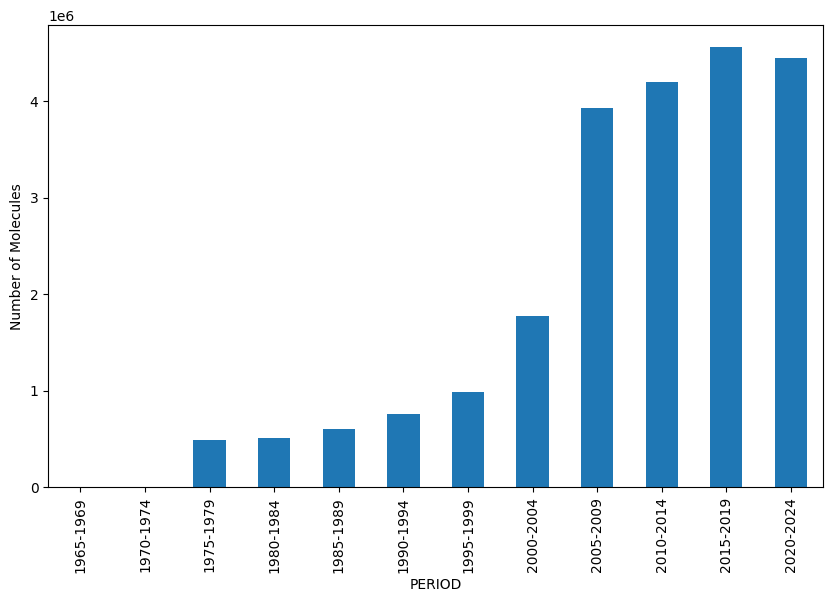

In [26]:
# 5years ごとに分割
bins =[1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, float('inf')]
labels = [
    '1965-1969', '1970-1974', '1975-1979',
    '1980-1984', '1985-1989', '1990-1994', 
    '1995-1999', '2000-2004', '2005-2009', 
    '2010-2014', '2015-2019', '2020-2024'
]
df['PERIOD'] = pd.cut(
    df['YEAR'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)


plt.figure(figsize=(10,6))
plt.xlabel("Patent Date")
plt.ylabel("Number of Molecules")
df['PERIOD'].value_counts().sort_index().plot(kind='bar')
plt.show()

In [32]:
print(f"Number of data points 1965-1970: {len(df[df['PERIOD']=='1965-1969'])}")
print(f"Number of data points 1970-1975: {len(df[df['PERIOD']=='1970-1974'])}")

Number of data points 1965-1970: 9
Number of data points 1970-1975: 2536


In [27]:
brics_cols = [f"BRICS_{j}" for j in range(16)]
result_df = df.groupby('PERIOD')[brics_cols].sum()

df_binary = df.copy()
df_binary[brics_cols] = (df_binary[brics_cols] > 0).astype(int)
result_df = df_binary.groupby('PERIOD')[brics_cols].sum()

/tmp/ipykernel_913804/3343921060.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_df = df.groupby('PERIOD')[brics_cols].sum()
/tmp/ipykernel_913804/3343921060.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_df = df_binary.groupby('PERIOD')[brics_cols].sum()


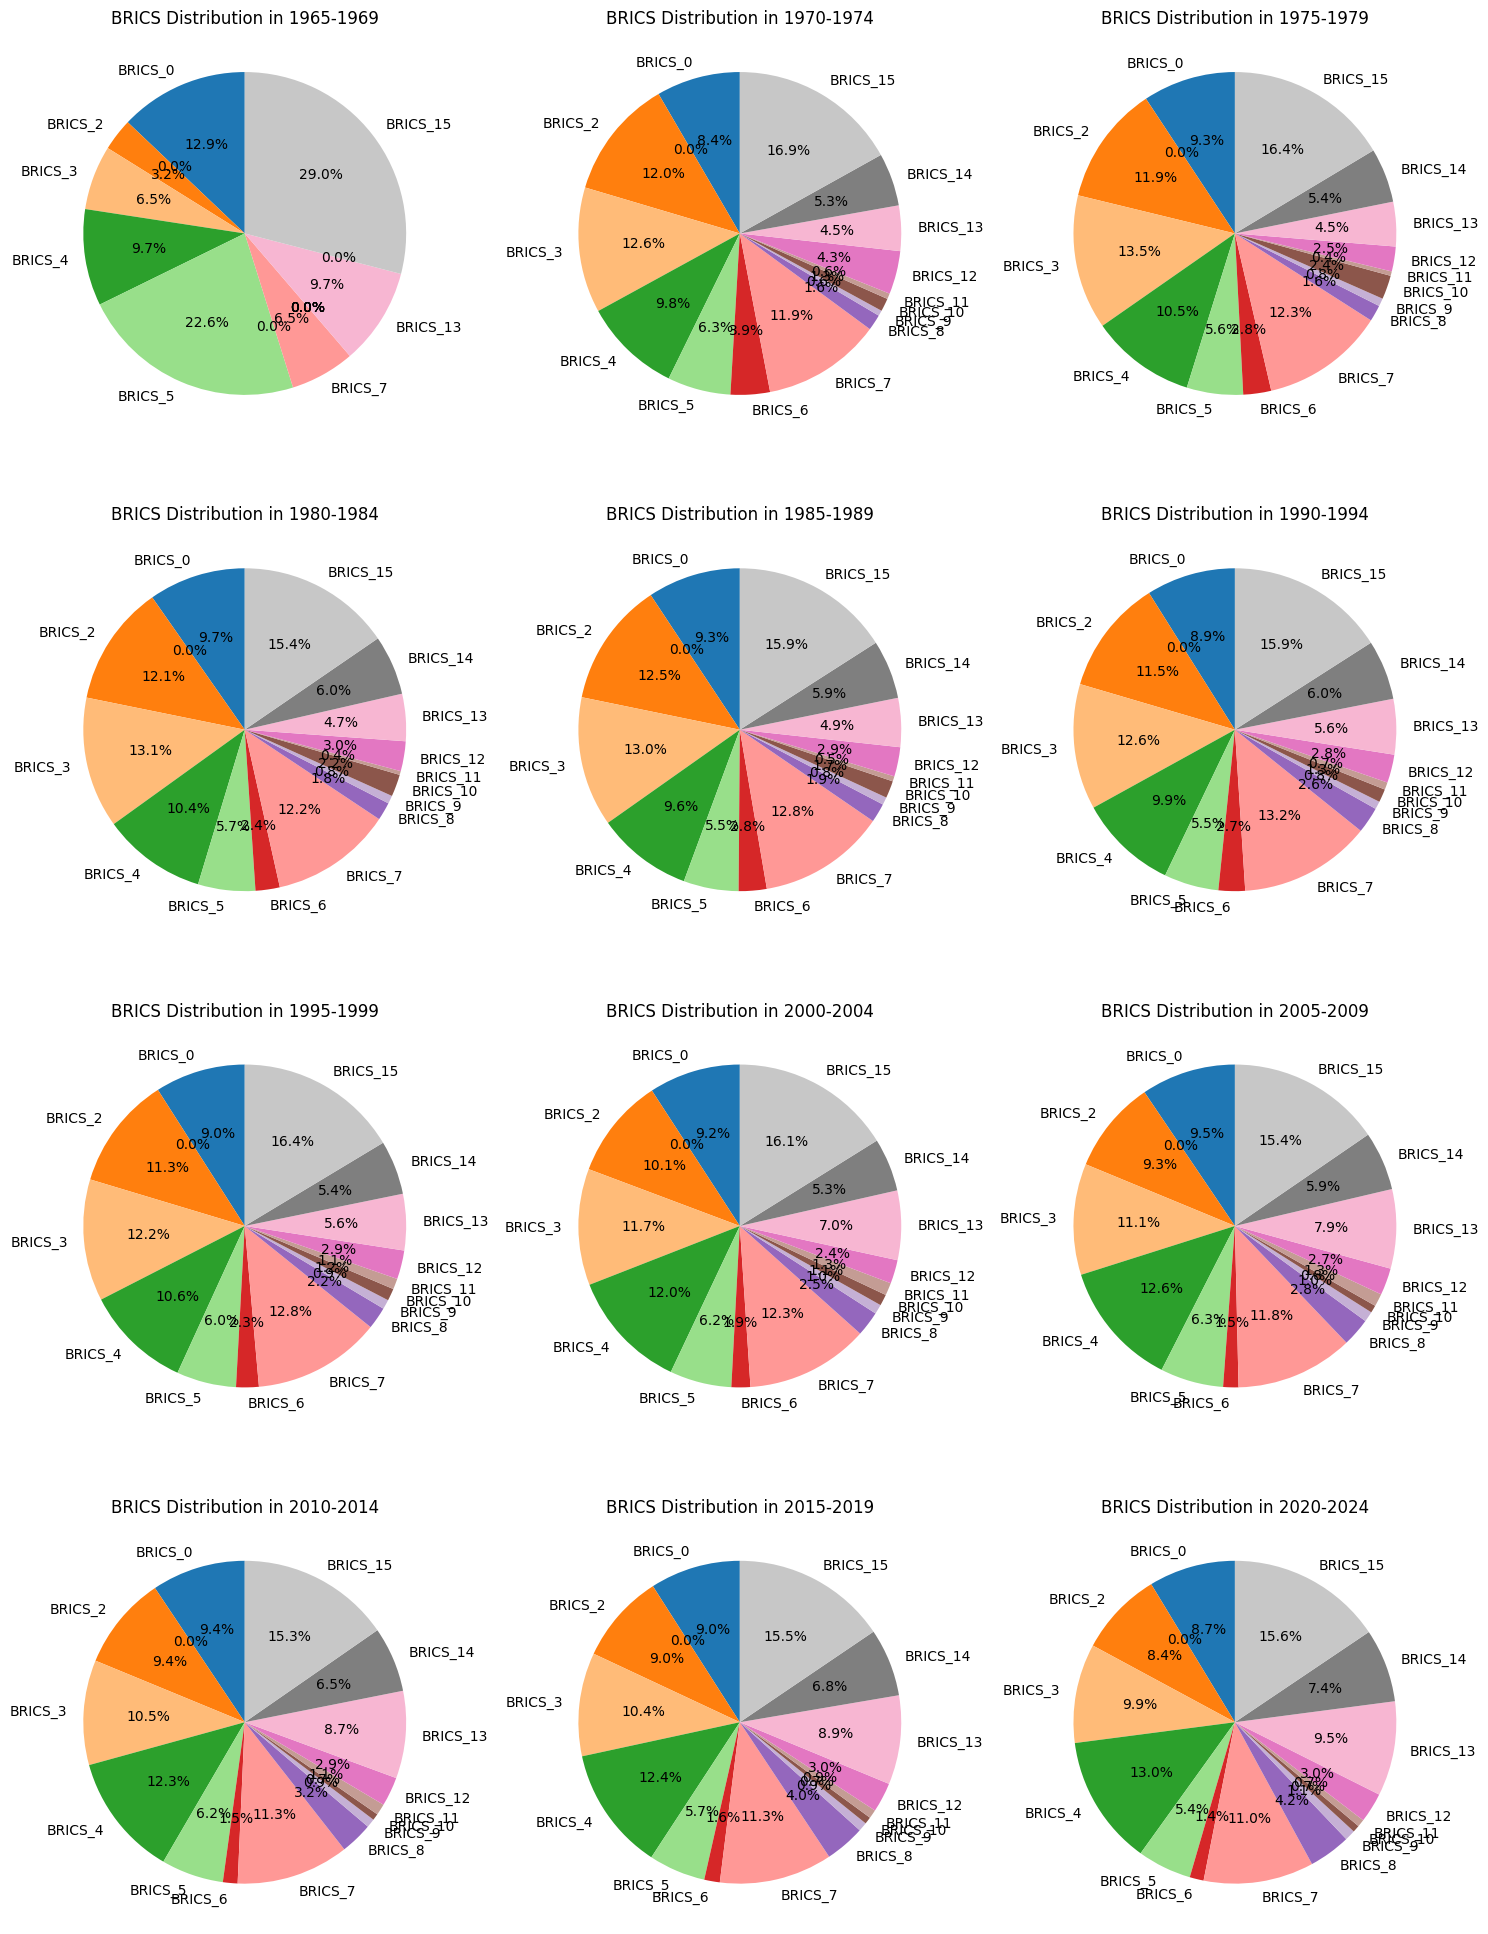

In [28]:
brics_ratio_df = result_df.div(result_df.sum(axis=1), axis=0)
periods = brics_ratio_df.index
n = len(periods)

cols = 3 
rows = -(-n // cols) 

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
axes = axes.flatten()

colors = plt.cm.tab20.colors

for i, period in enumerate(periods):
    ax = axes[i]
    brics_ratio_df.loc[period].plot.pie(
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        ax=ax
    )
    ax.set_title(f'BRICS Distribution in {period}')
    ax.set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


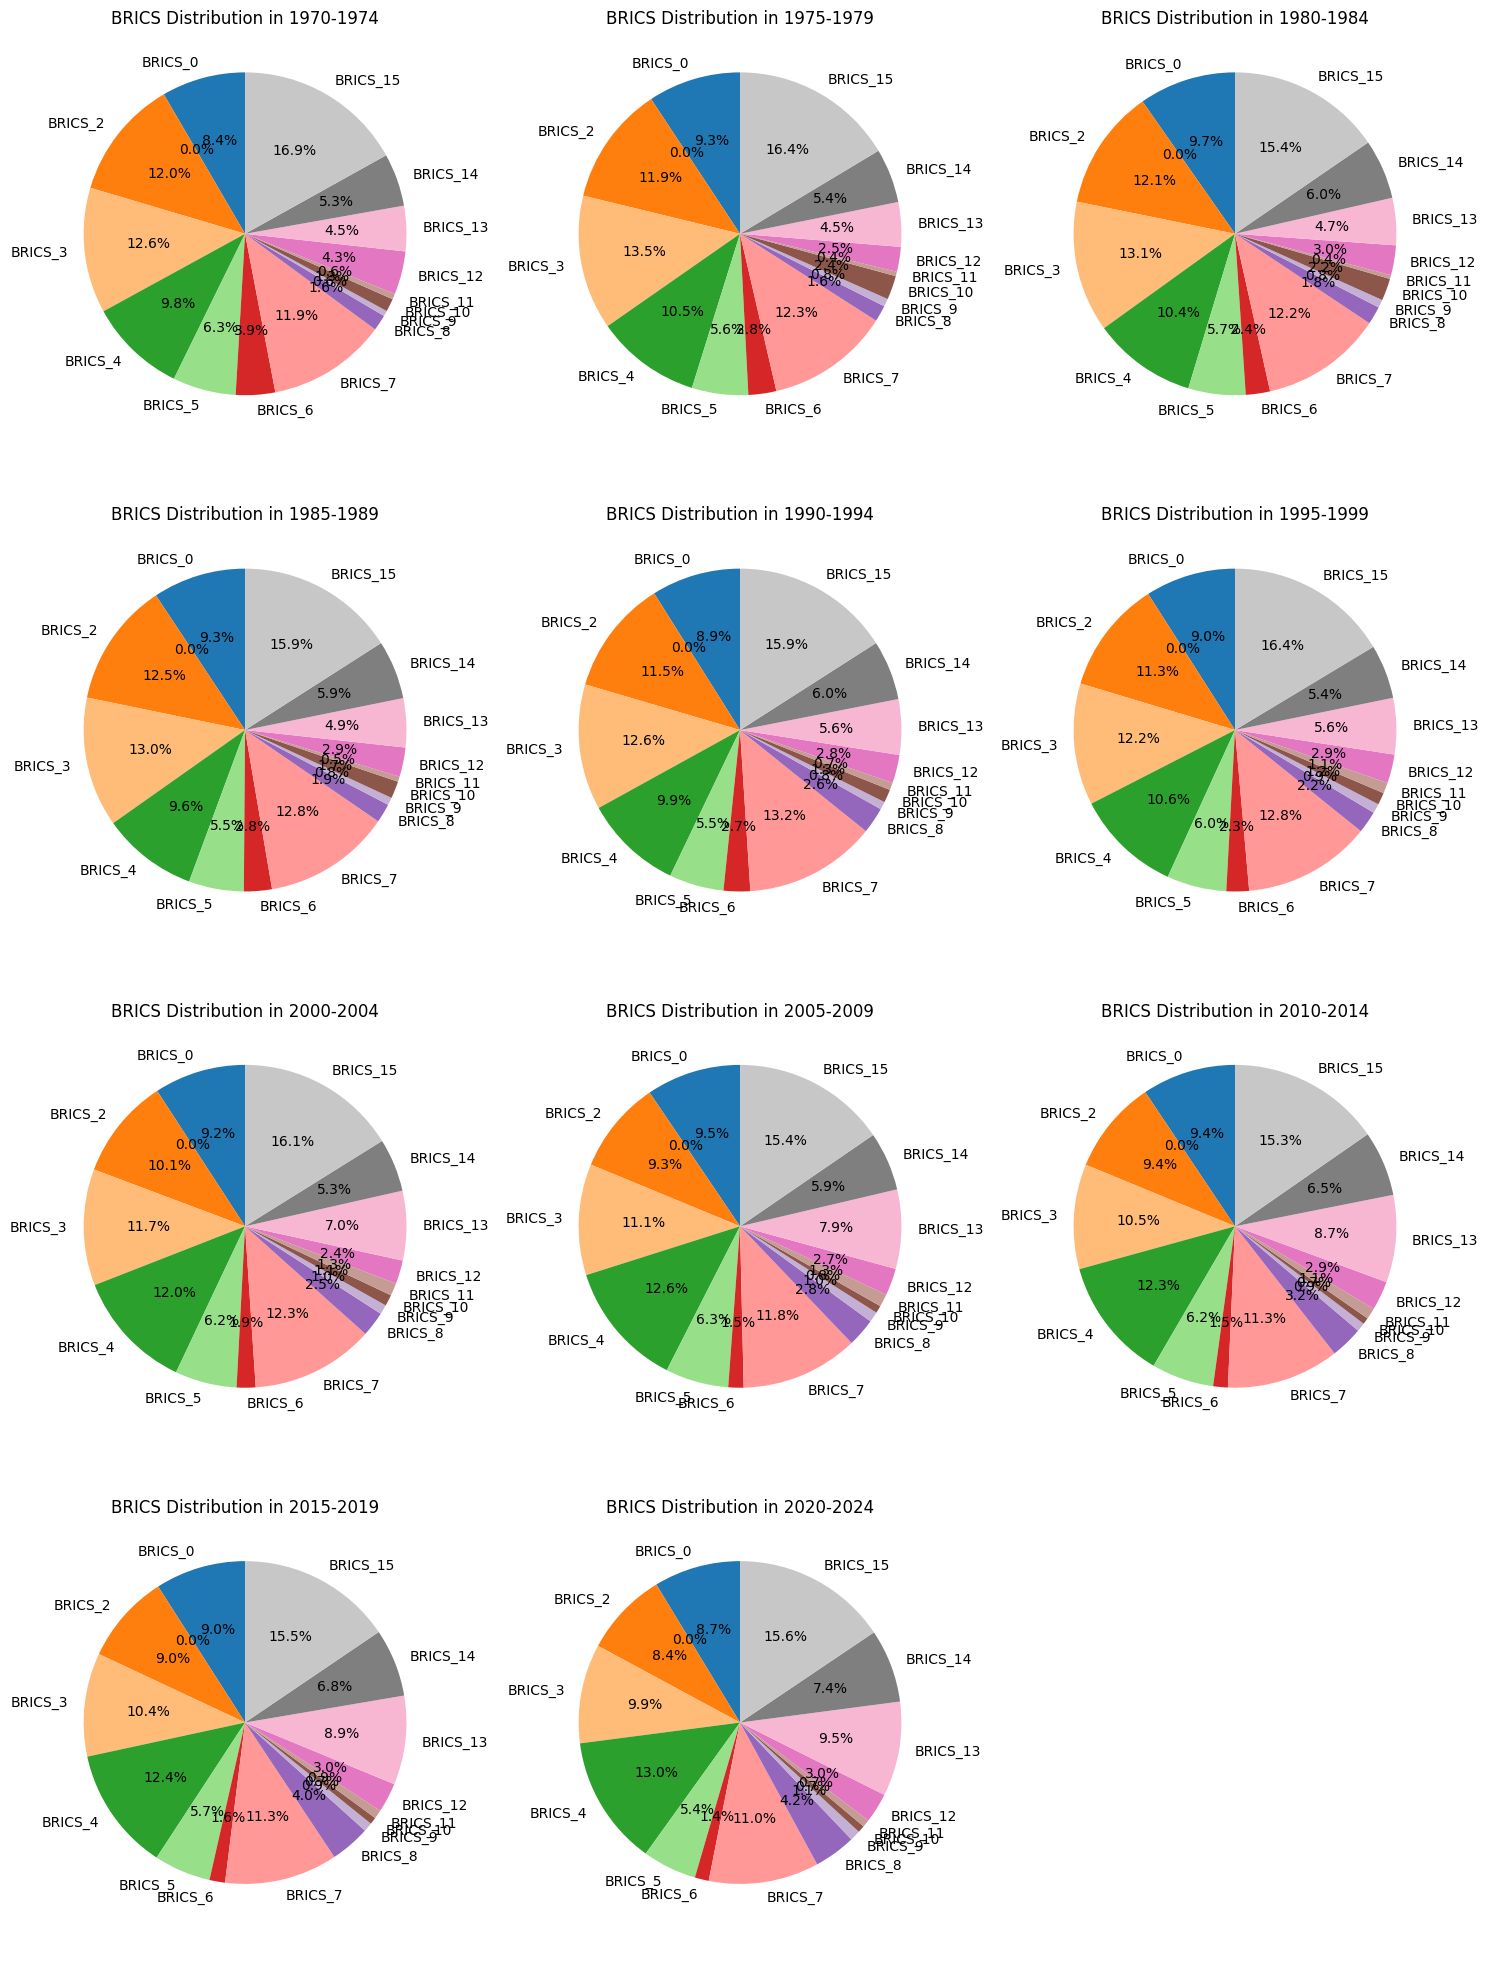

In [36]:
# only after 1970
brics_ratio_df_post1970 = brics_ratio_df.loc['1970-1974':]

periods = brics_ratio_df_post1970.index
n = len(periods)

cols = 3 
rows = -(-n // cols) 

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
axes = axes.flatten()

colors = plt.cm.tab20.colors

for i, period in enumerate(periods):
    ax = axes[i]
    brics_ratio_df_post1970.loc[period].plot.pie(
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        ax=ax
    )
    ax.set_title(f'BRICS Distribution in {period}')
    ax.set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

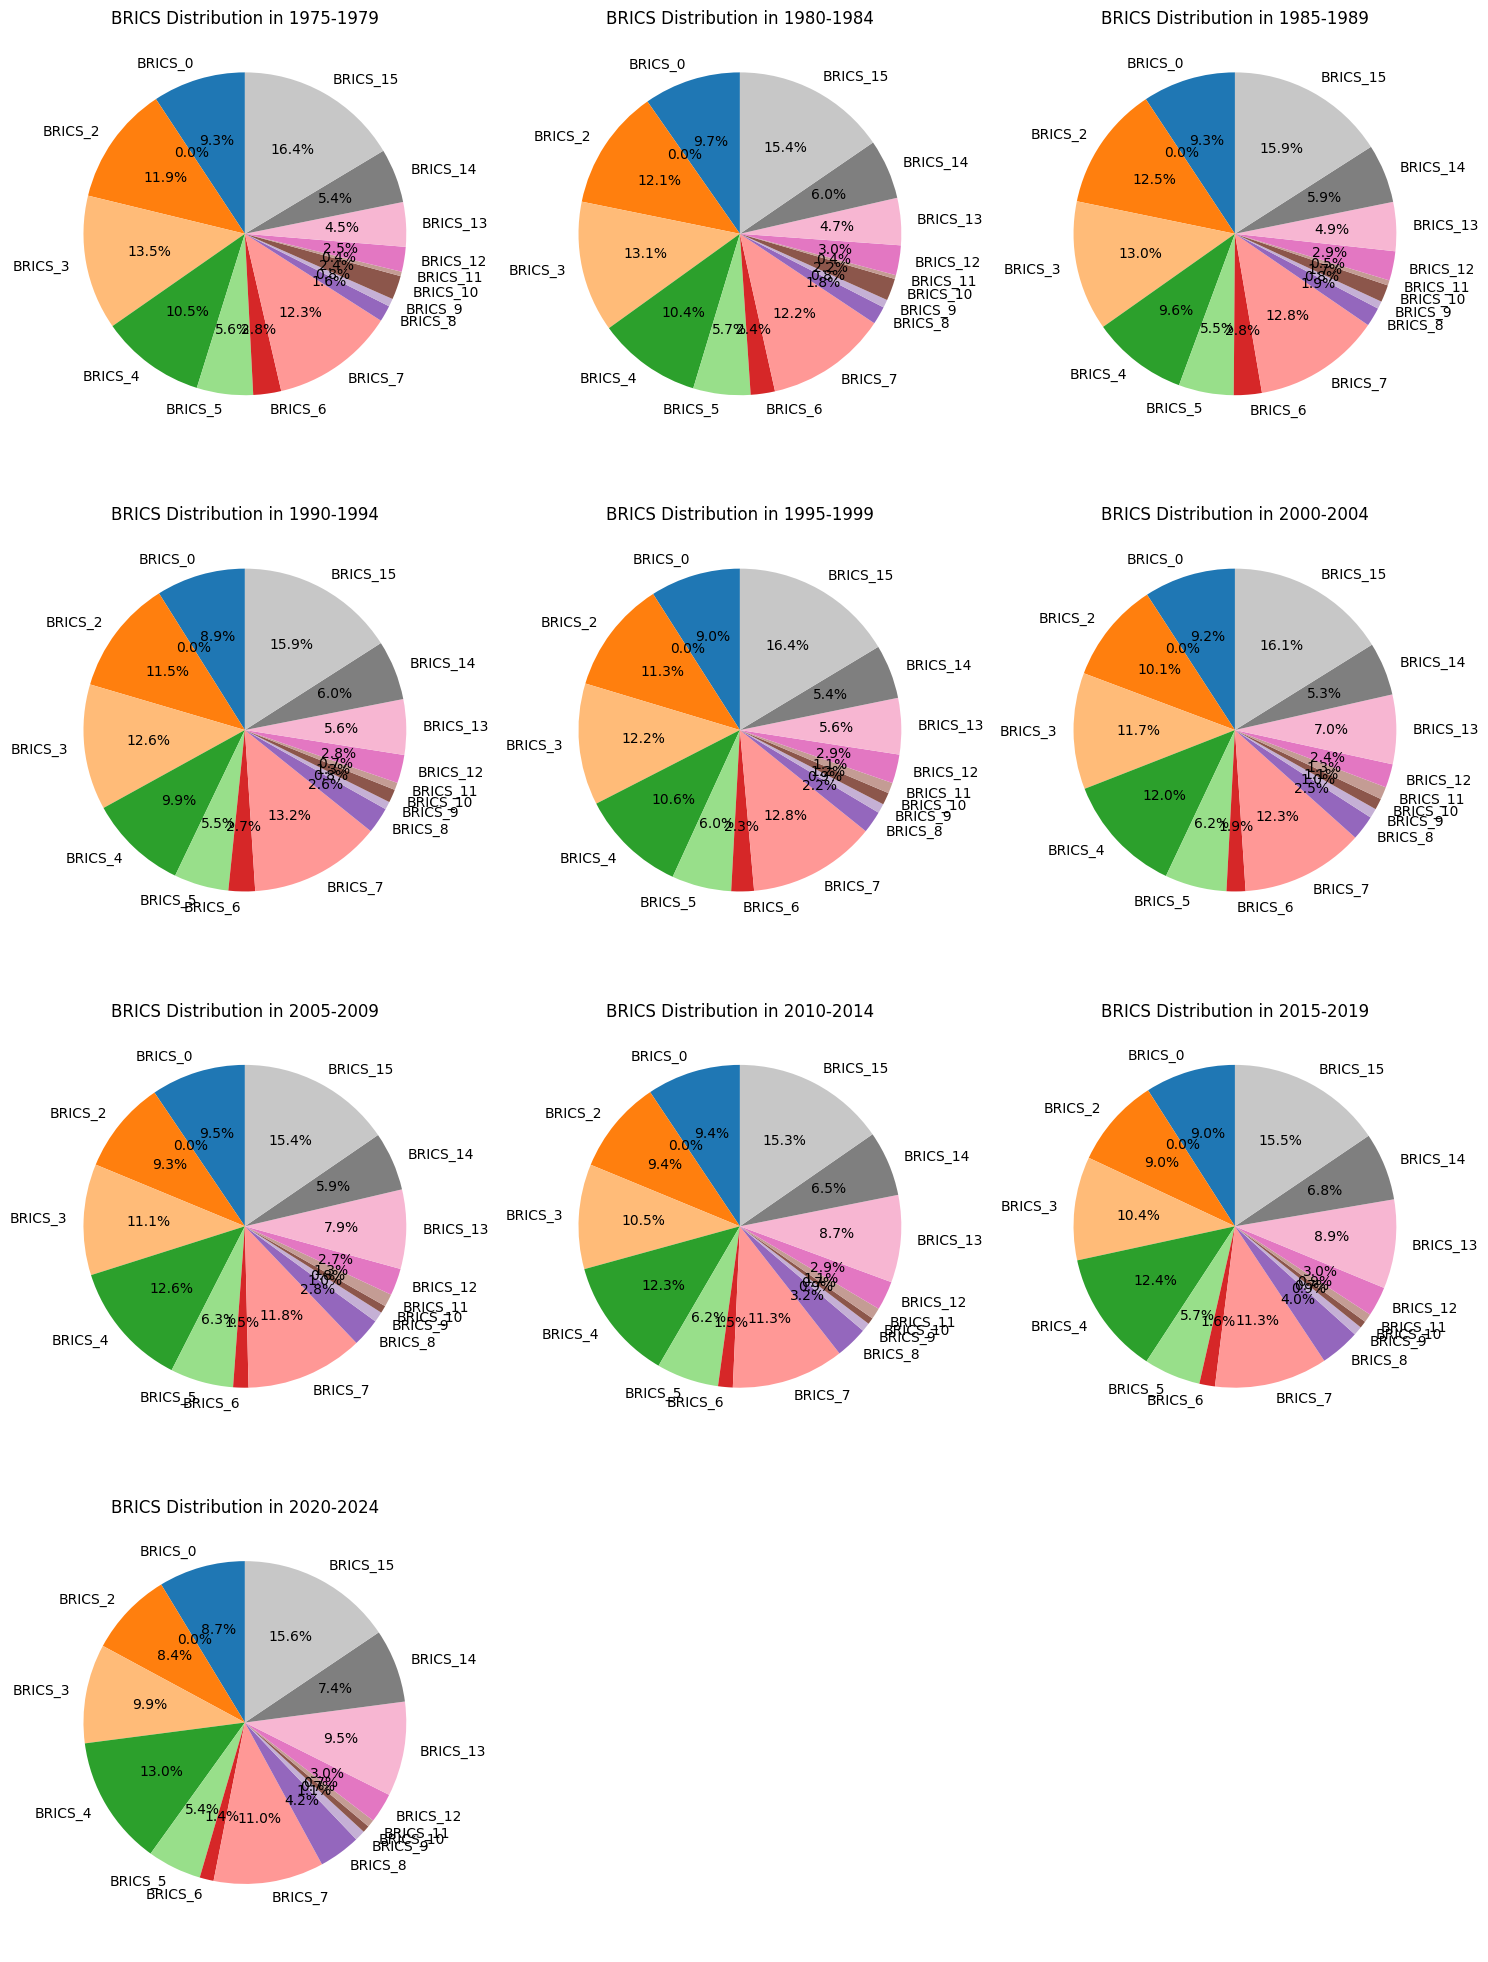

In [37]:
# only after 1975
brics_ratio_df_post1975 = brics_ratio_df.loc['1975-1979':]

periods = brics_ratio_df_post1975.index
n = len(periods)

cols = 3 
rows = -(-n // cols) 

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
axes = axes.flatten()

colors = plt.cm.tab20.colors

for i, period in enumerate(periods):
    ax = axes[i]
    brics_ratio_df_post1975.loc[period].plot.pie(
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        ax=ax
    )
    ax.set_title(f'BRICS Distribution in {period}')
    ax.set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

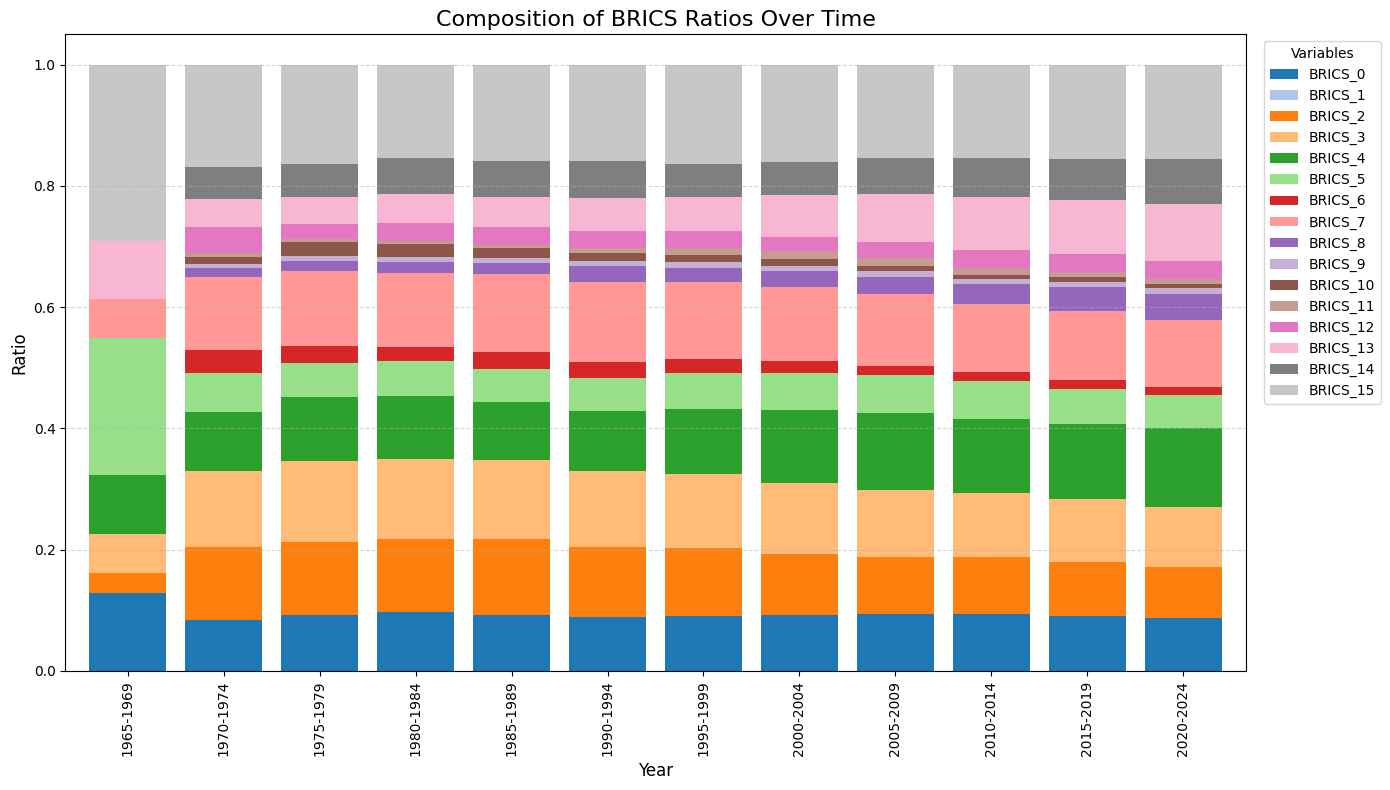

In [31]:
plt.figure(figsize=(12, 7))
colors = plt.cm.tab20.colors 
brics_ratio_df.plot(kind='bar', stacked=True, figsize=(14, 8), color=colors, width=0.8)

plt.title('Composition of BRICS Ratios Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Ratio', fontsize=12)
plt.legend(title='Variables', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('brics_stacked_bar.png')
plt.show()
plt.close()

<Figure size 1200x700 with 0 Axes>

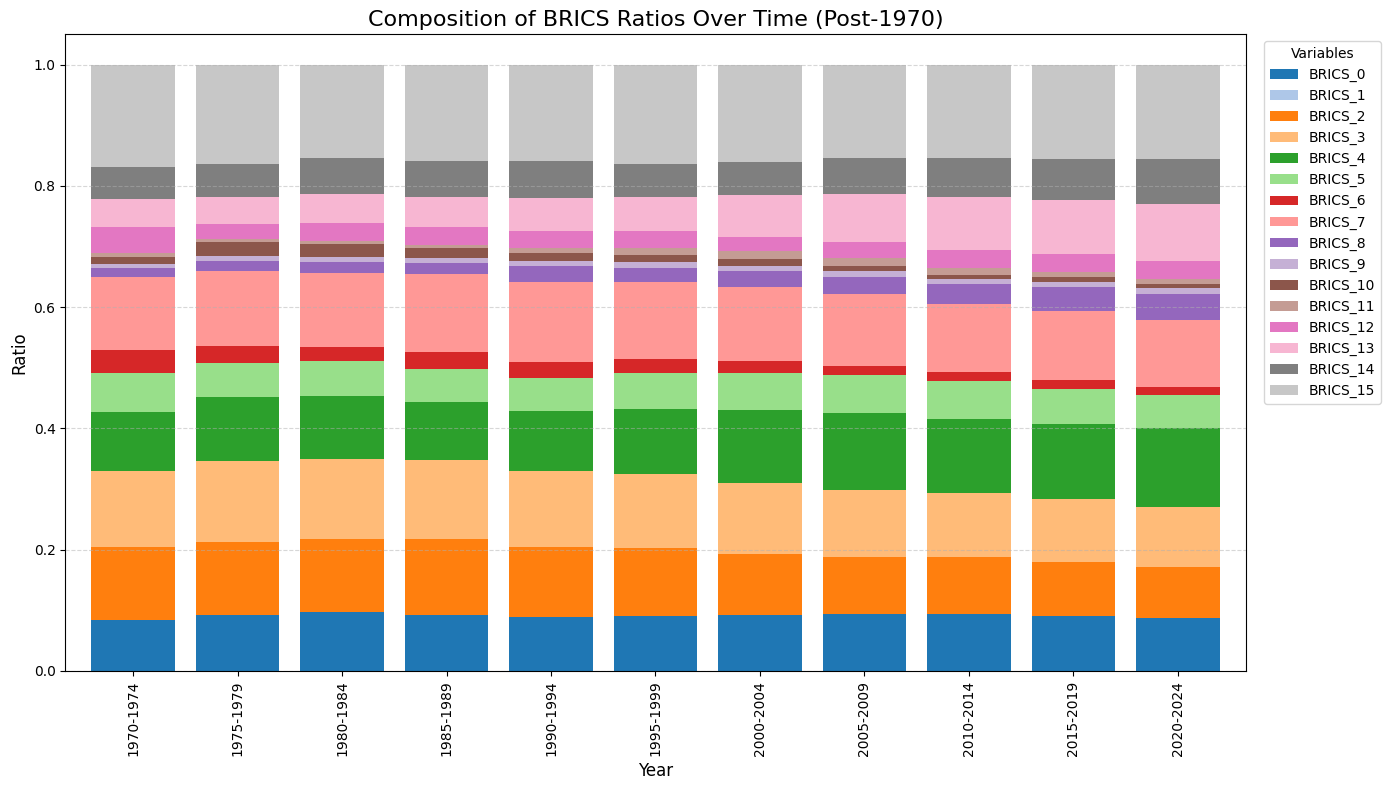

In [34]:
# only after 1970
brics_ratio_df_post1970 = brics_ratio_df.loc['1970-1974':]
plt.figure(figsize=(12, 7))
colors = plt.cm.tab20.colors 
brics_ratio_df_post1970.plot(kind='bar', stacked=True, figsize=(14, 8), color=colors, width=0.8)
plt.title('Composition of BRICS Ratios Over Time (Post-1970)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Ratio', fontsize=12)
plt.legend(title='Variables', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('brics_stacked_bar_post1975.png')
plt.show()
plt.close()

<Figure size 1200x700 with 0 Axes>

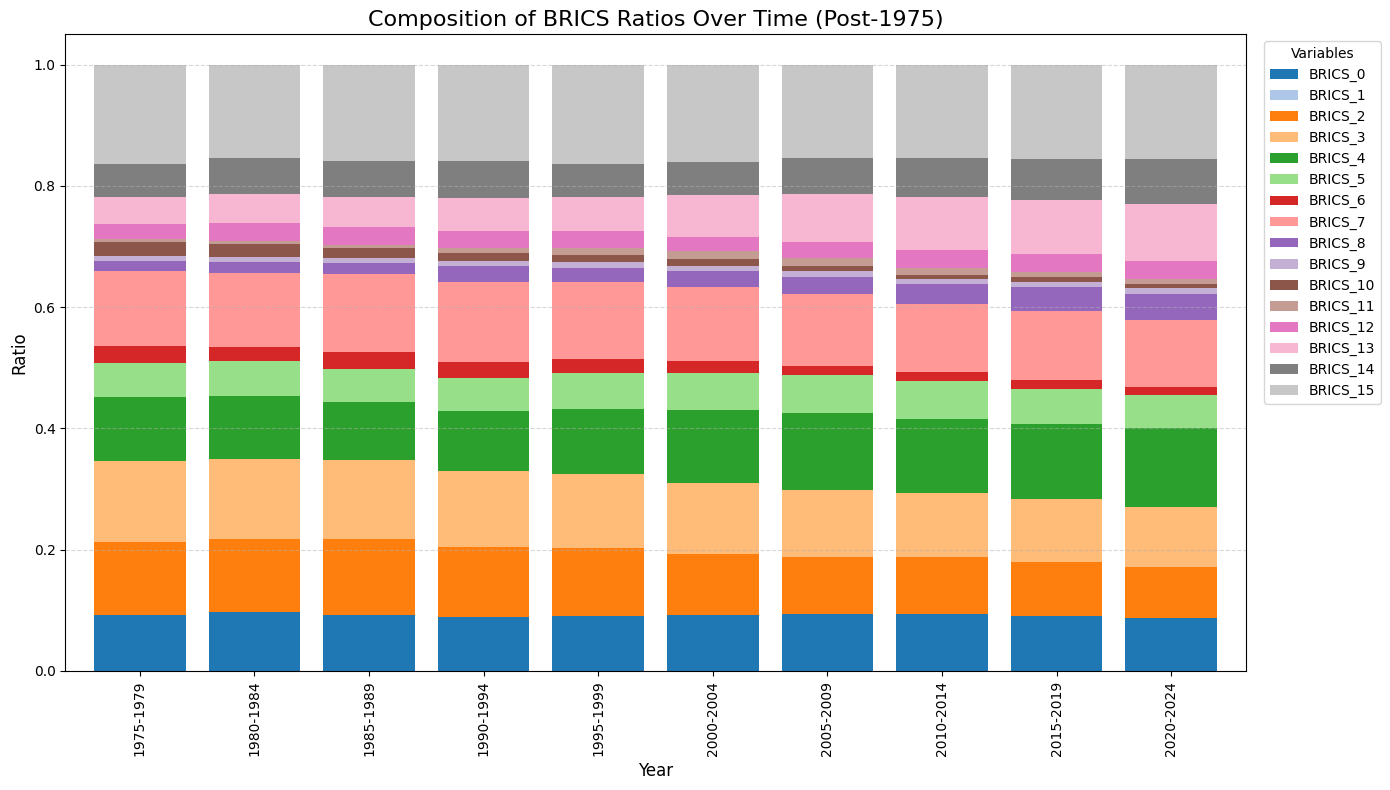

In [35]:
# only after 1975
brics_ratio_df_post1975 = brics_ratio_df.loc['1975-1979':]
plt.figure(figsize=(12, 7))
colors = plt.cm.tab20.colors 
brics_ratio_df_post1975.plot(kind='bar', stacked=True, figsize=(14, 8), color=colors, width=0.8)
plt.title('Composition of BRICS Ratios Over Time (Post-1975)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Ratio', fontsize=12)
plt.legend(title='Variables', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('brics_stacked_bar_post1975.png')
plt.show()
plt.close()

# murcko scaffold analysis

In [49]:
df = pd.read_csv("../../data/processed/surechembl/murcko_scaffold_properties_with_date.csv")

In [50]:
df.head()

,Scaffold,MW,LogP,Fsp3,H_Donors,RingCount,DATE,5_Year_Bin
0,C1=CCc2cc3cc4ccccc4cc3cc2C1,230.310,4.6478,0.111111,0.0,4.0,1962.082,1960.0
1,C1=CNc2ccccc2C(c2ccccn2)=N1,221.263,2.8157,0.000000,1.0,3.0,1963.616,1960.0
2,C1=NC=C(c2cccnc2)Nc2ccccc21,221.263,2.9246,0.000000,1.0,3.0,1963.616,1960.0
3,C1CC[C@@]2(C[C@@H]3C4CC[C@@H]5C6CCCCC6CC[C@H]5...,344.539,5.5508,1.000000,0.0,6.0,1965.129,1965.0
4,C1CC[C@@]2(C[C@@H]3C4CC[C@@H]5C6CCCC[C@H]6CC[C...,344.539,5.5508,1.000000,0.0,6.0,1965.129,1965.0


In [52]:
df_clean = df.dropna(subset=['DATE', 'Scaffold']).copy()
df_clean = df_clean.sort_values('DATE')
bins =[1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, float('inf')]
labels = [
    '1965-1969', '1970-1974', '1975-1979',
    '1980-1984', '1985-1989', '1990-1994', 
    '1995-1999', '2000-2004', '2005-2009', 
    '2010-2014', '2015-2019', '2020-2024'
]
df_clean['PERIOD'] = pd.cut(
    df_clean['DATE'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

cumulative_counts = Counter()
results = []
last_idx = 0

print("Calculating Cumulative Diversity...")

for year_threshold in labels:
    target_idx = df_clean['PERIOD'].searchsorted(year_threshold)
    new_batch = df_clean.iloc[last_idx:target_idx]['Scaffold']
    cumulative_counts.update(new_batch)
    last_idx = target_idx

    total_records = sum(cumulative_counts.values())
    unique_scaffolds = len(cumulative_counts)
    
    shannon = 0
    if total_records > 0:
        counts = np.array(list(cumulative_counts.values()))
        p = counts / total_records
        shannon = -np.sum(p * np.log(p))

    results.append({
        'Year_Threshold': year_threshold,
        'Cumulative_Diversity': shannon,
        'Unique_Scaffold_Count': unique_scaffolds,
        'Total_Records': total_records
    })

res_df = pd.DataFrame(results)

Calculating Cumulative Diversity...


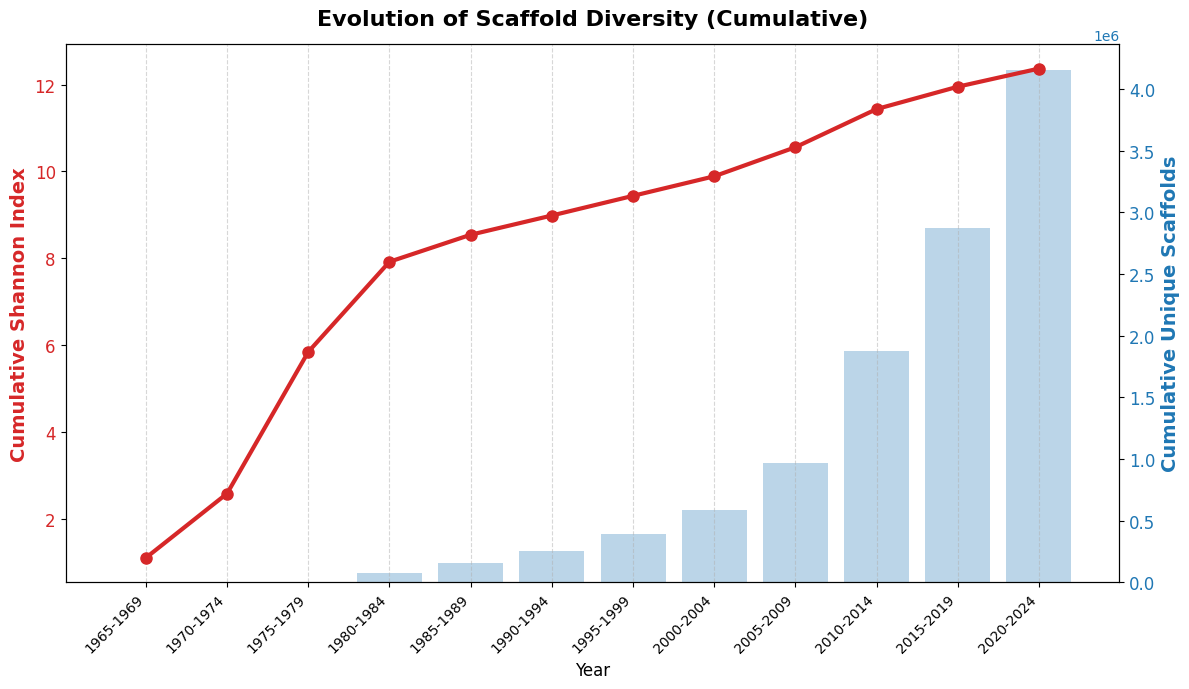

In [55]:
fig, ax1 = plt.subplots(figsize=(12, 7))
color1 = '#d62728'
color2 = '#1f77b4'

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Cumulative Shannon Index', color=color1, fontsize=14, fontweight='bold')
ax1.plot(res_df['Year_Threshold'], res_df['Cumulative_Diversity'], color=color1, marker='o', linewidth=3, markersize=8, label='Shannon Index')
ax1.tick_params(axis='y', labelcolor=color1, labelsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
ax1.grid(axis='x', linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
ax2.set_ylabel('Cumulative Unique Scaffolds', color=color2, fontsize=14, fontweight='bold')
ax2.bar(res_df['Year_Threshold'], res_df['Unique_Scaffold_Count'], color=color2, alpha=0.3, width=0.8, label='Unique Count', zorder=1)
ax2.tick_params(axis='y', labelcolor=color2, labelsize=12)
ax1.set_zorder(2) 
ax1.patch.set_visible(False) 

plt.title('Evolution of Scaffold Diversity (Cumulative)', fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

/tmp/ipykernel_913804/3166630051.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PERIOD', y=prop, data=df_clean, ax=ax, palette="Blues", showfliers=False)
/tmp/ipykernel_913804/3166630051.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = df_clean.groupby('PERIOD', sort=False)[prop].median()
/tmp/ipykernel_913804/3166630051.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PERIOD', y=prop, data=df_clean, ax=ax, palette="Blues", showfliers=False)
/tmp/ipykernel_913804/31666300

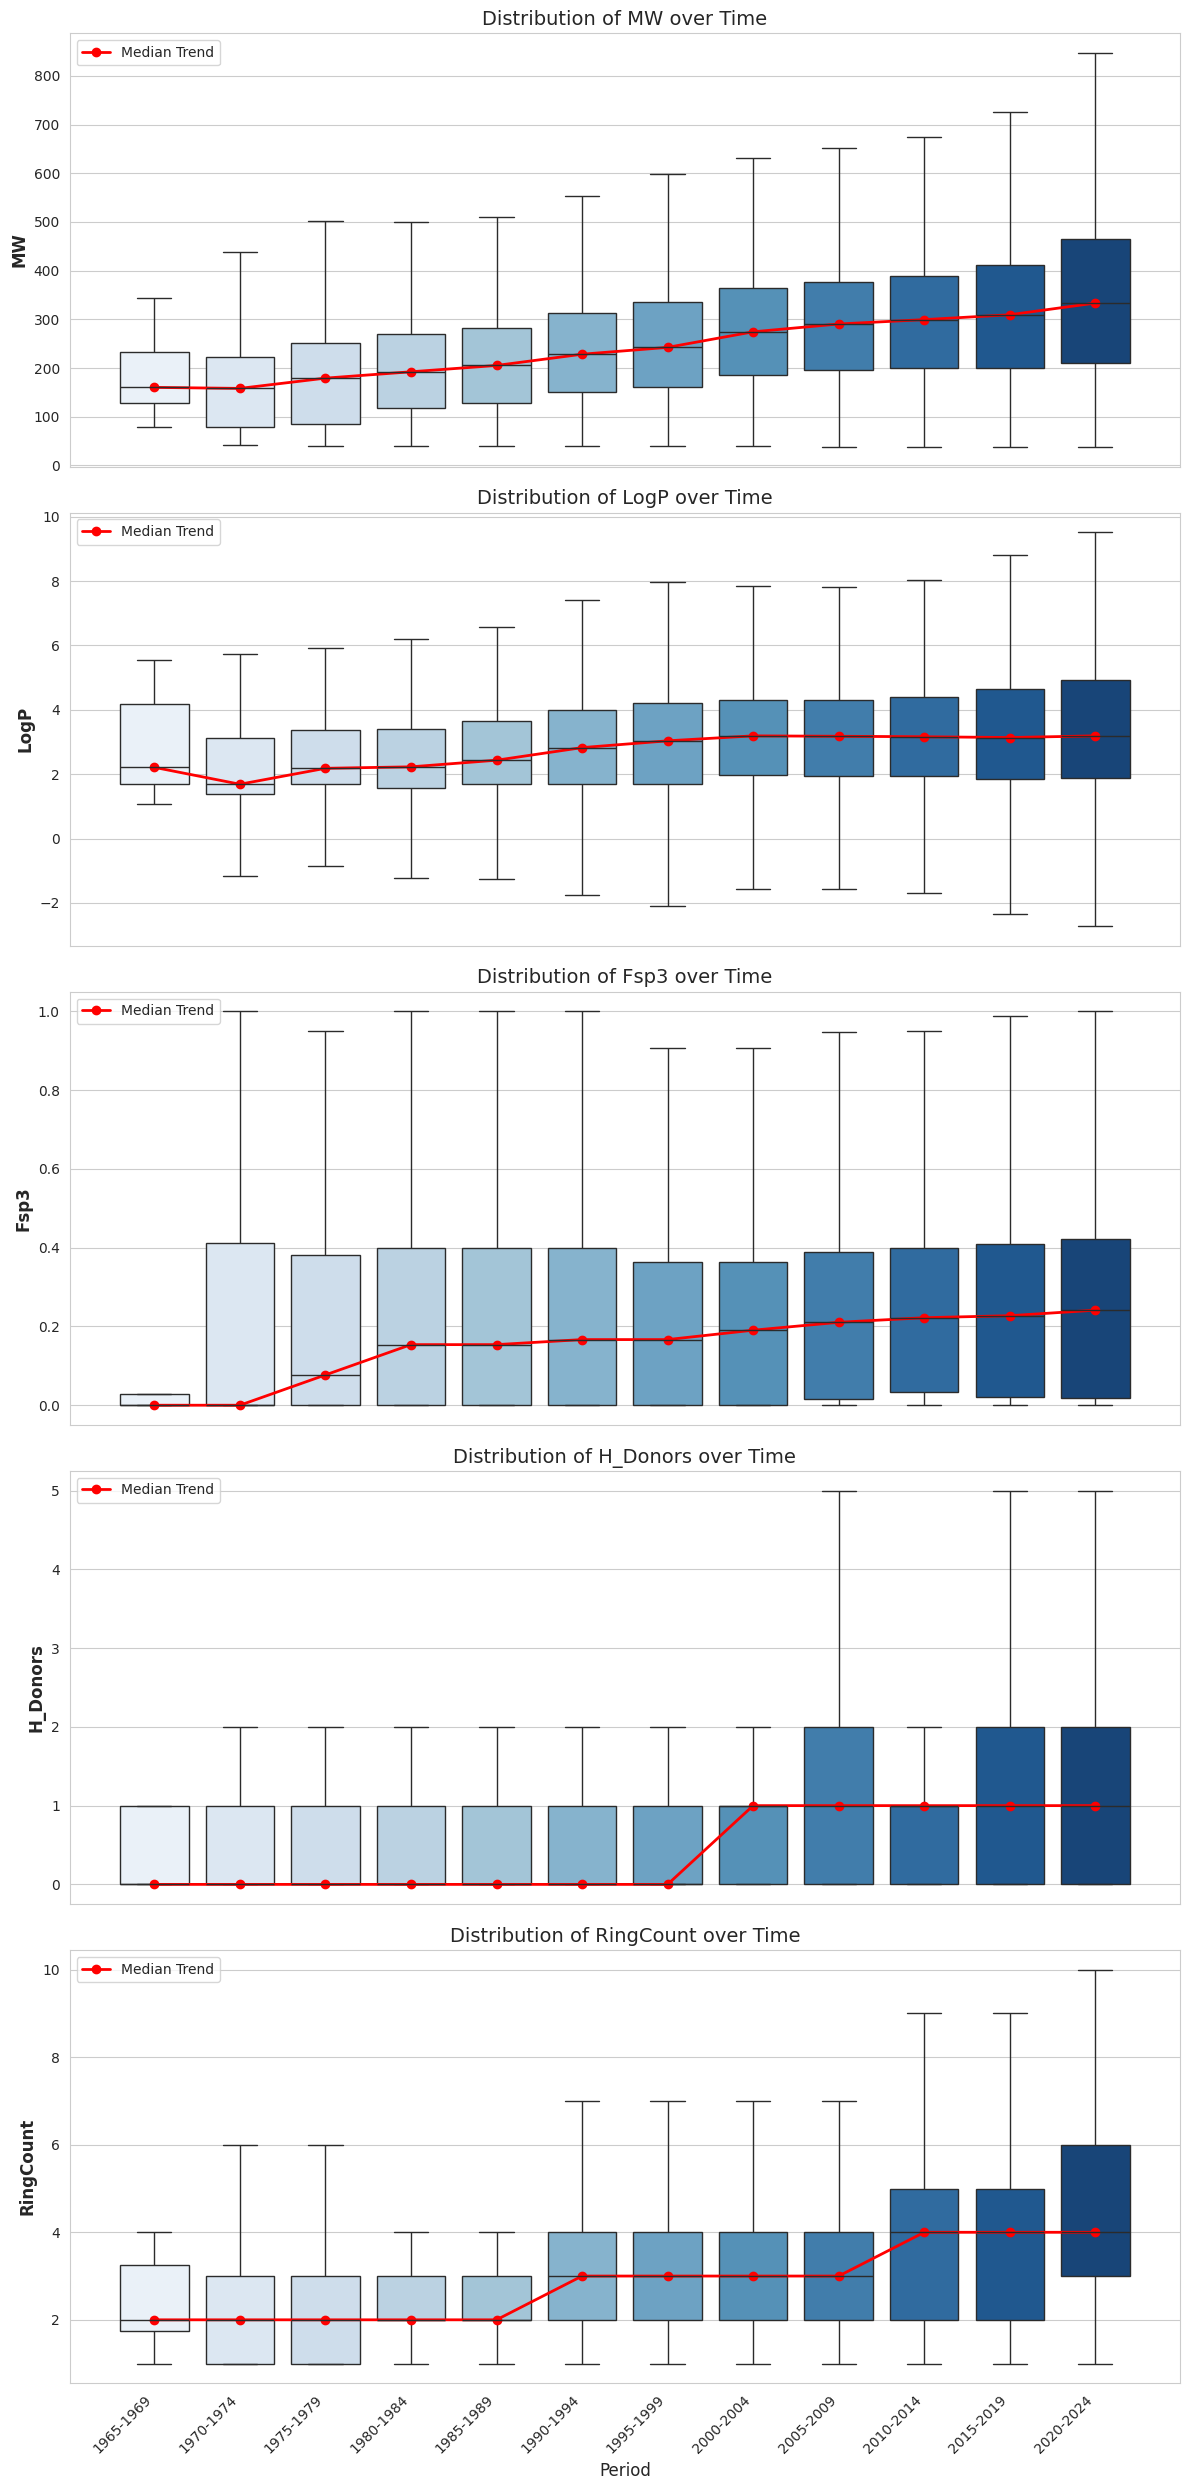

In [57]:
# df_clean = df.dropna(subset=['DATE', 'Scaffold', 'MW', 'LogP', 'Fsp3', 'H_Donors', 'RingCount']).copy()
# df_clean = df_clean.sort_values('DATE')
# bins =[1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, float('inf')]
# labels = [
#     '1965-1969', '1970-1974', '1975-1979',
#     '1980-1984', '1985-1989', '1990-1994', 
#     '1995-1999', '2000-2004', '2005-2009', 
#     '2010-2014', '2015-2019', '2020-2024'
# ]
# df_clean['PERIOD'] = pd.cut(
#     df_clean['DATE'],
#     bins=bins,
#     labels=labels,
#     right=False,
#     include_lowest=True
# )

properties = ['MW', 'LogP', 'Fsp3', 'H_Donors', 'RingCount']

fig, axes = plt.subplots(len(properties), 1, figsize=(12, 5 * len(properties)), sharex=True)
sns.set_style("whitegrid")

for i, prop in enumerate(properties):
    ax = axes[i]
    sns.boxplot(x='PERIOD', y=prop, data=df_clean, ax=ax, palette="Blues", showfliers=False)
    medians = df_clean.groupby('PERIOD', sort=False)[prop].median()
    ax.plot(range(len(medians)), medians.values, color='red', marker='o', linewidth=2, label='Median Trend')
    
    ax.set_ylabel(prop, fontsize=12, fontweight='bold')
    ax.set_title(f'Distribution of {prop} over Time', fontsize=14)
    ax.legend(loc='upper left')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel('Period', fontsize=12)
plt.tight_layout()
plt.show()